# Event Content Forecasting

**Plan:**
- Configure the event in `config.py` (name, anchor dates, forecast year)
- Load historical data (two years back)
- Classify content as Evergreen / Spontaneous using SetFit
- Discover evergreen topics with BERTopic
- Compute YoY impression trends
- Project next-year volumes per topic
- Estimate spontaneous uncertainty budget
- Output interactive HTML report with per-day recommendations

**Pipeline:**

1. **Classify content** as Evergreen / Spontaneous using SetFit → `data/classified.csv`
2. **Find topics** with BERTopic → `data/with_topics.csv`
3. **Forecast** daily impressions by content type & topic → `data/{FORECAST_YEAR}_*.csv`
4. **Visualize** topics and forecast results
5. **YoY trends** — temporal alignment, YoY breakdown, topic projections → CSVs
6. **Report** — spontaneous budget + interactive HTML report with per-day recommendations

> **To switch events:** edit `config.py` — update `EVENT_NAME`, `EVENT_KEY`, `EVENT_ANCHORS`, and `FORECAST_YEAR`.


## Step 1 — Classify Content

Runs SetFit to label each article as **Evergreen** or **Spontaneous**.  
Saves `data/classified.csv`.


In [1]:
%run 1-classify-content.py


/Users/mitsou/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Imports OK
Event: Halloween (halloween) | article language: fr


The tokenizer you are loading from 'setfit_evergreen_model_fr' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicted: data/2024.csv
content_type
Evergreen      32820
Spontaneous    30851


The tokenizer you are loading from 'setfit_evergreen_model_fr' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicted: data/2025.csv
content_type
Spontaneous    20402
Evergreen      18363
Rows after 'fr' language filter: 91,507
Saved: data/classified.csv


Uncomment `# train("data/2025_claude.csv")` once labelled training data is ready.


## Step 2 — Find Topics

Runs BERTopic to group articles into topics per content type.  
Saves `data/with_topics.csv`.


In [2]:
%run 2-find-topics.py


An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'
Imports OK
Evergreen: topics found: 17 | outlier articles: 10,420 | min_topic_size: 50
Spontaneous: topics found: 17 | outlier articles: 18,529 | min_topic_size: 50
[LLM] Labeled 34 topics via Gemini
Saved: data/topic_descriptions.csv
Saved: data/with_topics.csv


## Step 3 — Forecast

Applies YoY growth factors to project daily impressions by content type and topic.  
Saves `data/{FORECAST_YEAR}_daily_impression_forecast_by_content_type.csv` and `..._by_topic.csv`.


In [3]:
%run 3-forecast.py

Saved: data/2026_daily_impression_forecast_by_content_type.csv
year          forecast_impressions_2026  forecast_articles_2026
content_type                                                   
Evergreen                         64710                    9623
Spontaneous                     1568599                   11370
Saved: data/2026_daily_impression_forecast_by_topic.csv
content_type  topic_key       topic_label                       
Evergreen     Evergreen_-1    _outlier                               11537
              Evergreen_0     DIY & Family Crafts                    12880
              Evergreen_1     Creative Food & Makeup                  7614
              Evergreen_10    Printable Halloween Crafts              1603
              Evergreen_11    Printable Halloween Characters           915
              Evergreen_13    Kitten Coloring Pages                     16
              Evergreen_14    Halloween Music & Events                   8
              Evergreen_15    Netfl

## Step 4 — Visualize

Topic distribution per content type, daily forecast by content type, and daily forecast by topic.


In [4]:
%run 4-visualize.py


## Step 5 — YoY Trends & Topic Projections

Temporal alignment, volume curves per year, YoY breakdown, and impressions projected per topic using YoY growth.  
Saves `data/timing_all.csv`, `data/timing_by_year.csv`, `data/yoy_breakdown.csv`, `data/2026_topic_projections.csv`.


Loaded 91,481 rows from data/with_topics.csv
Rows with valid dates: 91,481
Years covered: [np.int32(2024), np.int32(2025)]
Evergreen articles: 46,230

Top 5 days by impressions:
 days_to_event  articles  impressions
            -3      1949        79152
            -4      1795        76195
            -6      1757        66508
           -17      1115        64692
            -5      1814        59608


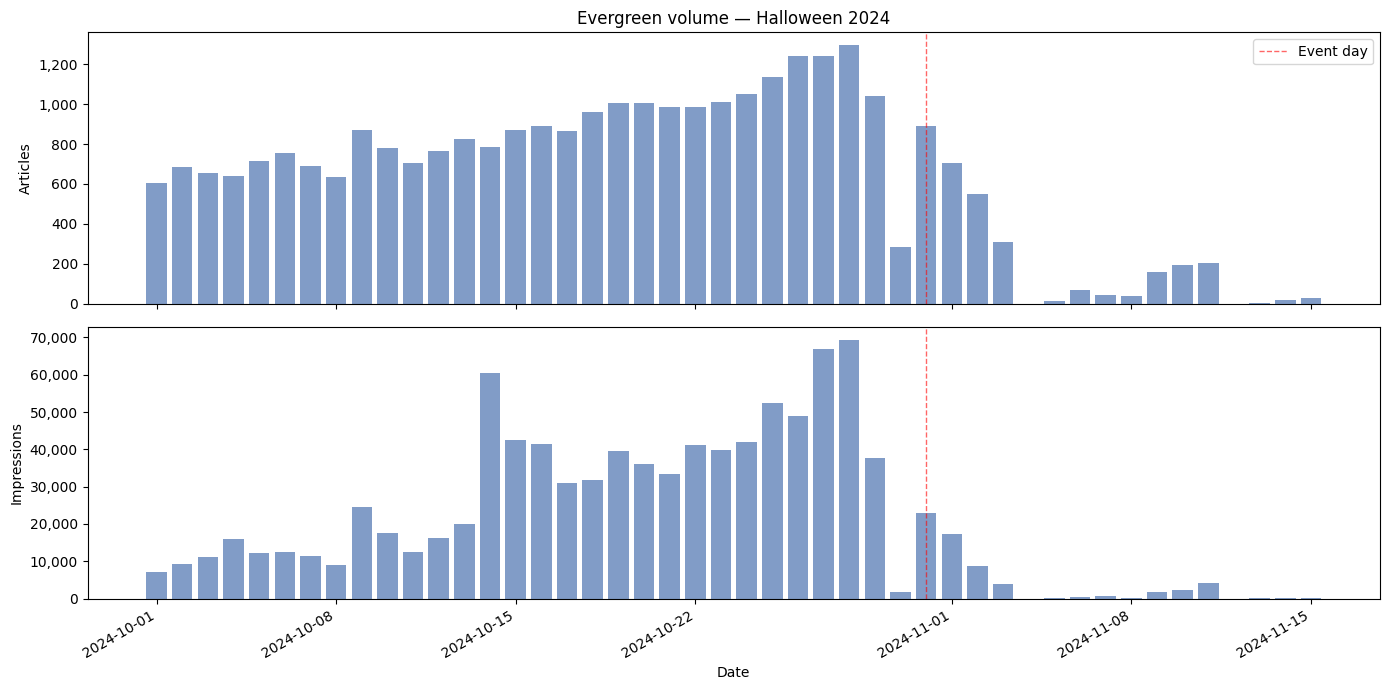

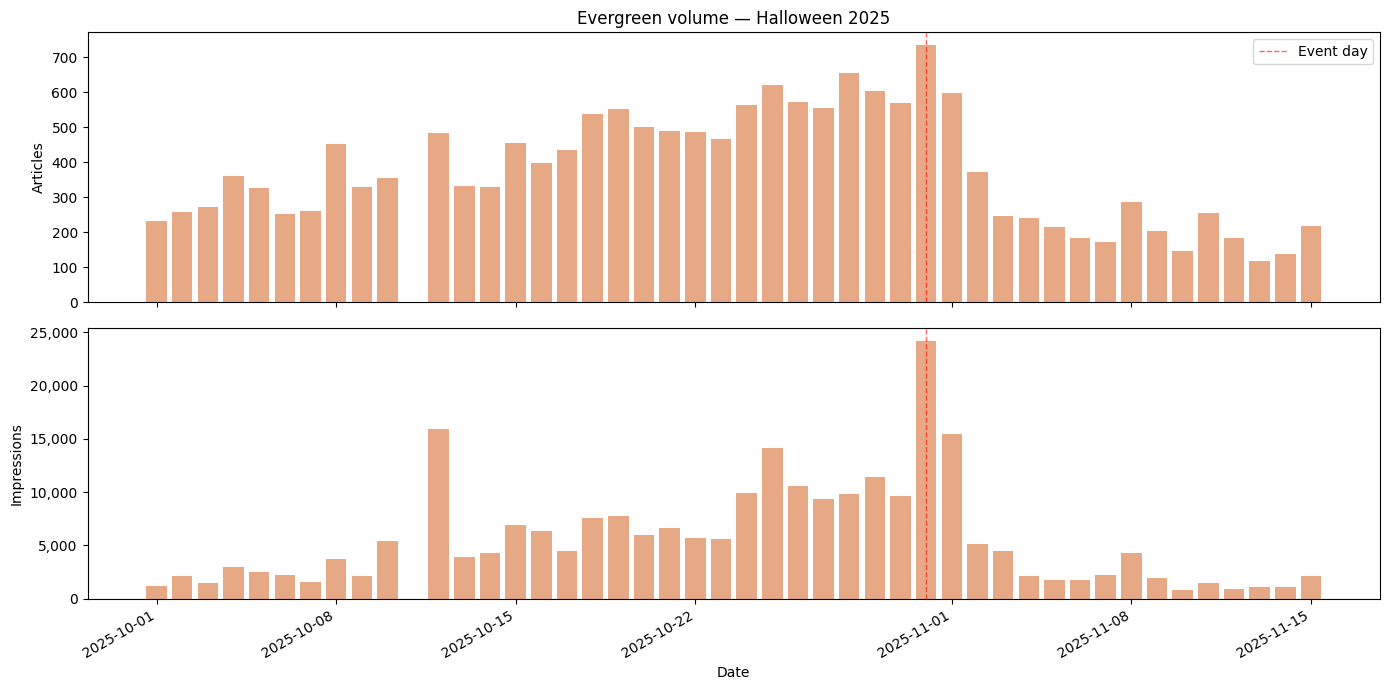

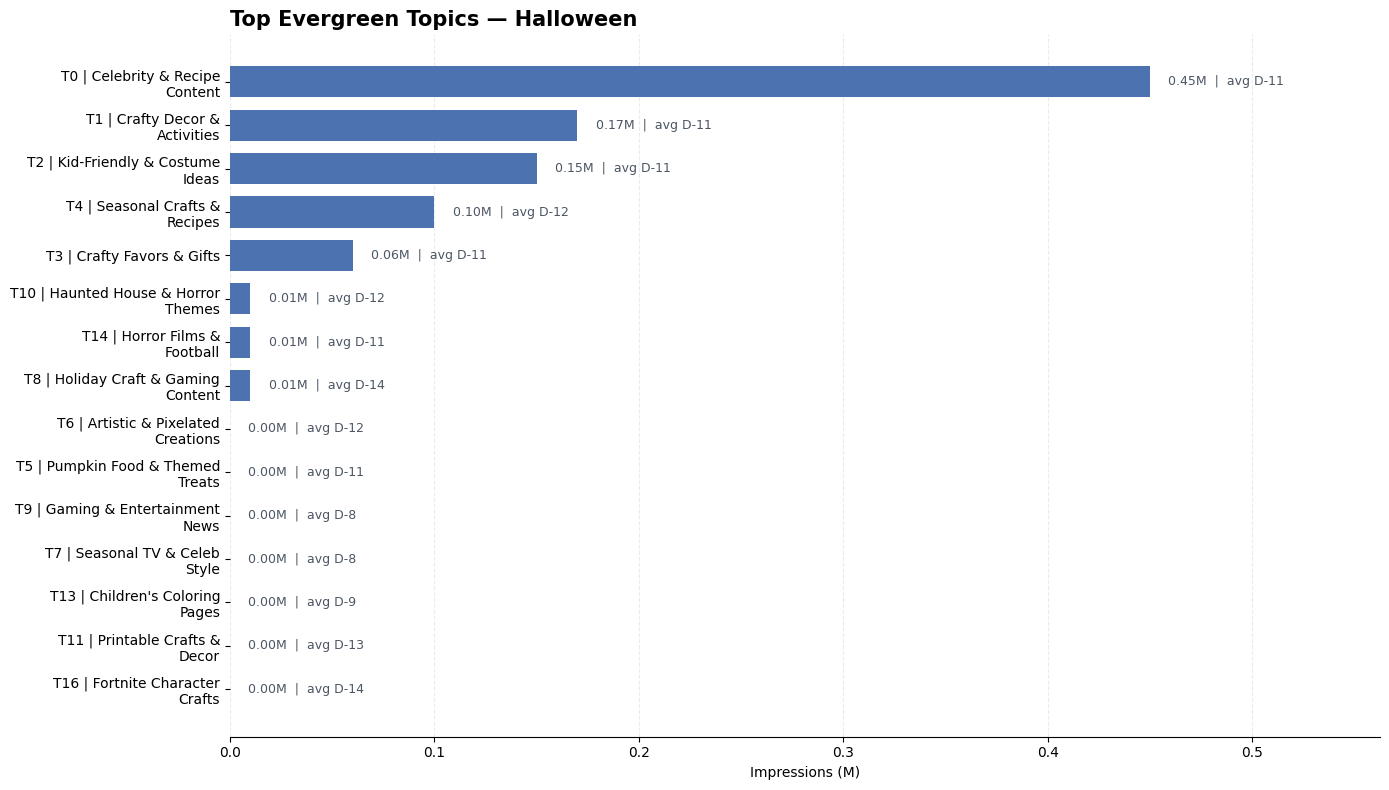


=== YEAR-OVER-YEAR BREAKDOWN ===
                       topic_label  articles_2024  articles_2025  impressions_M_2024  impressions_M_2025  articles_growth  impressions_M_growth
0       Celebrity & Recipe Content           8162           5044            0.379425            0.069125            -38.2                 -81.8
1        Crafty Decor & Activities           4941           2883            0.108550            0.058627            -41.7                 -46.0
2     Kid-Friendly & Costume Ideas           4952           2811            0.111465            0.034347            -43.2                 -69.2
3        Seasonal Crafts & Recipes           1253            788            0.070081            0.027873            -37.1                 -60.2
4            Crafty Favors & Gifts           1206            865            0.050874            0.011874            -28.3                 -76.7
5    Haunted House & Horror Themes             79             64            0.012097            0.0019

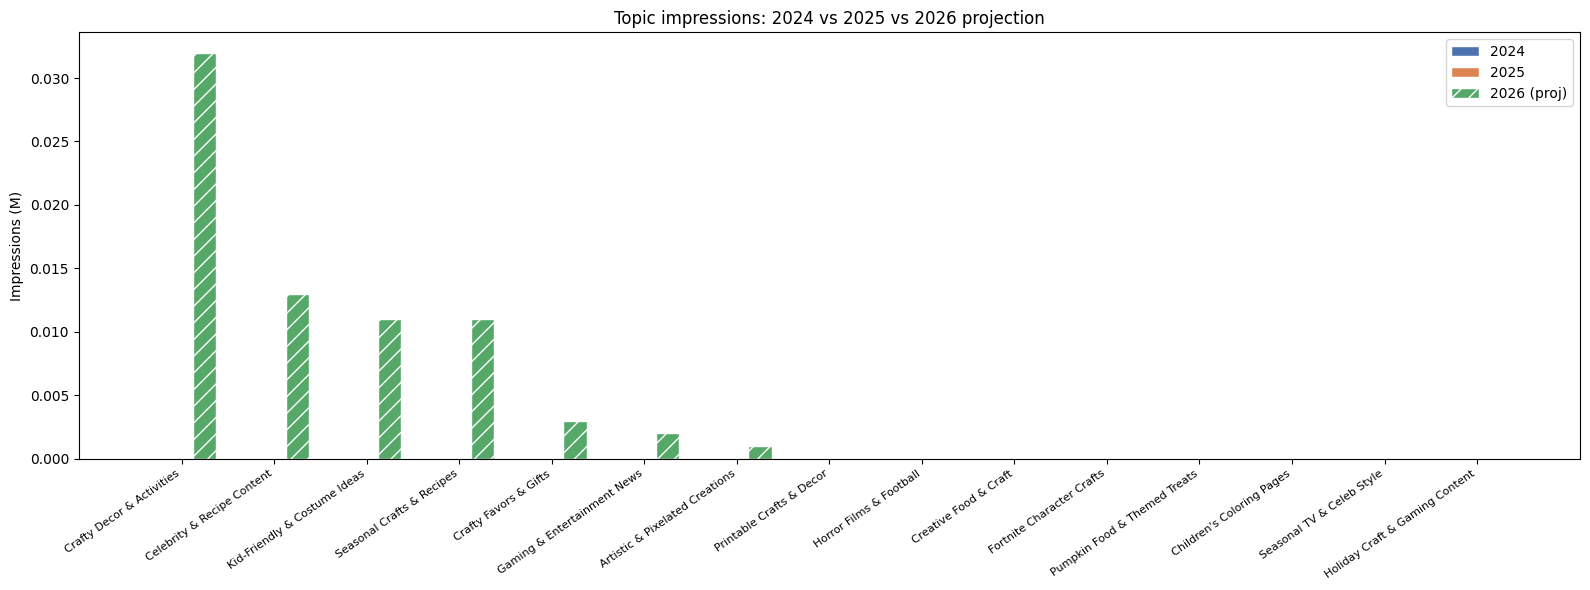


=== 2026 FORECAST PER TOPIC ===
                       topic_label  articles_2026_proj  impressions_M_2026_proj  avg_days_to_event        window
0        Crafty Decor & Activities            1680.789                    0.032              -11.0  D-30 to D+15
1       Celebrity & Recipe Content            3117.192                    0.013              -10.6  D-30 to D+15
2     Kid-Friendly & Costume Ideas            1596.648                    0.011              -10.5  D-30 to D+15
3        Seasonal Crafts & Recipes             495.652                    0.011              -11.6  D-30 to D+15
4            Crafty Favors & Gifts             620.205                    0.003              -11.0  D-30 to D+15
5      Gaming & Entertainment News              30.951                    0.002               -7.7  D-30 to D+15
6   Artistic & Pixelated Creations              65.340                    0.001              -11.8  D-30 to D+15
7         Printable Crafts & Decor              20.916         

In [8]:
%run 5-yoy-trends.py


## Step 6 — Report

Computes spontaneous uncertainty budget and generates the interactive HTML report with per-day content recommendations.  
Saves `{EVENT_KEY}_{FORECAST_YEAR}_forecast_report_v2.html` and `data/{EVENT_KEY}_{FORECAST_YEAR}_recommendations.csv`.


In [7]:
%run 6-report.py


=== SPONTANEOUS BASELINE BY YEAR ===
 year content_type  articles  pct_articles  impressions_M  pct_impressions
 2024    Evergreen     29254          51.7          0.965             50.0
 2024  Spontaneous     27342          48.3          0.967             50.0
 2025    Evergreen     16997          48.7          0.251             16.8
 2025  Spontaneous     17914          51.3          1.243             83.2

Avg spontaneous share → 2026 budget: 66.6%
HTML report : halloween_2026_forecast_report_v2.html
Reco CSV    : data/halloween_2026_recommendations.csv

  HALLOWEEN 2026 — FORECAST SUMMARY
  Evergreen impressions : 64,710
  Spontaneous budget    : ~1,087,784  (66.6%)
  Total projected       : ~1,633,309

  Top 5 topics:
    • Pumpkin Decor & Recipes                       14,363 imps  |  D-30 to D+15
    • DIY & Family Crafts                           12,880 imps  |  D-30 to D+15
    • Creative Food & Makeup                        7,614 imps  |  D-30 to D+15
    • Autumnal Crafts & D

In [ ]:

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from config import EVENT_NAME, EVENT_ANCHOR, FORECAST_YEAR

fc = pd.read_csv(f"data/{FORECAST_YEAR}_daily_impression_forecast_by_content_type.csv")
fc["date"] = pd.to_datetime(fc["date"])

colors = {"Evergreen": "#4C72B0", "Spontaneous": "#DD8452"}
_imps_col  = f"forecast_impressions_{FORECAST_YEAR}"
_arts_col  = f"forecast_articles_{FORECAST_YEAR}"

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=("Forecast Articles per Day", "Forecast Impressions per Day"),
    vertical_spacing=0.1,
)

for ct, color in colors.items():
    sub = fc[fc["content_type"] == ct].sort_values("date")
    fig.add_trace(go.Bar(
        x=sub["date"], y=sub[_arts_col],
        name=ct, marker_color=color,
        legendgroup=ct,
        hovertemplate="%{x|%d %b}<br>Articles: %{y:,.0f}<extra>" + ct + "</extra>",
    ), row=1, col=1)
    fig.add_trace(go.Bar(
        x=sub["date"], y=sub[_imps_col],
        name=ct, marker_color=color,
        legendgroup=ct, showlegend=False,
        hovertemplate="%{x|%d %b}<br>Impressions: %{y:,.0f}<extra>" + ct + "</extra>",
    ), row=2, col=1)

for row in [1, 2]:
    fig.add_vline(
        x=int(EVENT_ANCHOR.timestamp() * 1000),
        line_dash="dash", line_color="red",
        annotation_text="Event day" if row == 1 else "",
        annotation_position="top right",
        row=row, col=1,
    )

fig.update_layout(
    title=f"{EVENT_NAME} {FORECAST_YEAR} — Daily Forecast by Content Type",
    barmode="stack",
    xaxis2_title="Date",
    yaxis_title="Articles",
    yaxis2_title="Impressions",
    height=650,
    legend=dict(orientation="h", y=1.04, x=0),
)
fig.show()
